In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

In [5]:
# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [6]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [7]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [8]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [9]:
# 4. Create fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [10]:
# 5. Bin age into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

In [11]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])


In [12]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [13]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']


In [14]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [15]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [16]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [18]:
# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [19]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



In [21]:
# ----- ADVANCED FEATURE ENGINEERING -----

In [22]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [23]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [24]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [25]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

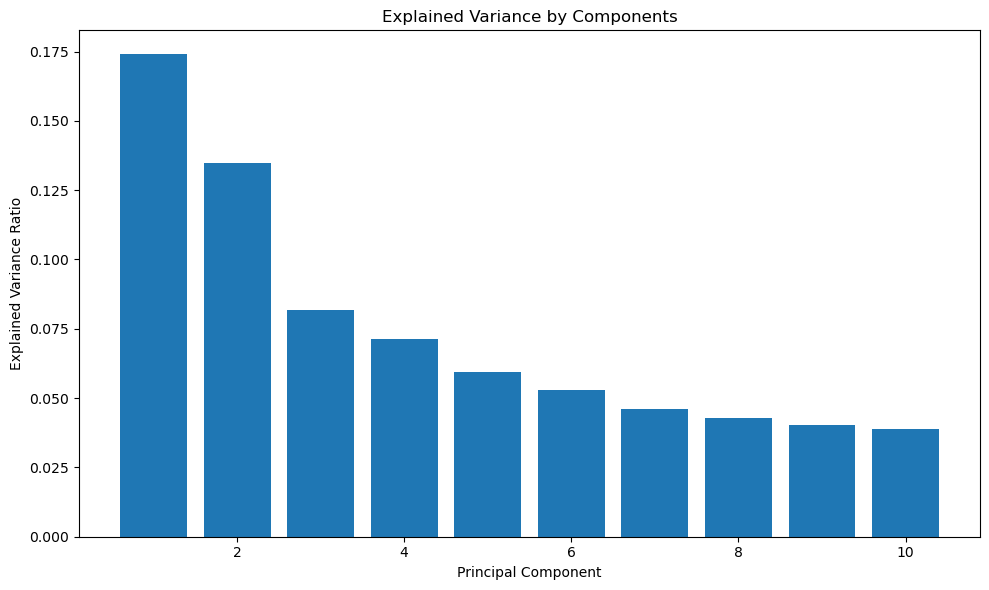

In [26]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [27]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


In [28]:
# ----- DATA AUGMENTATION FOR IMAGES -----

In [29]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

In [30]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [31]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)

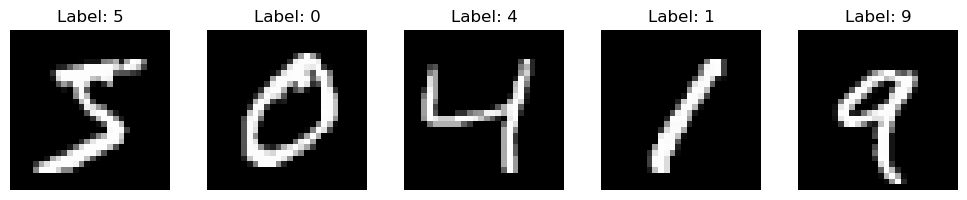

In [32]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [33]:
# ----- 1. BASIC IMAGE AUGMENTATION WITH KERAS -----

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    # brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [34]:
# Visualize augmented images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

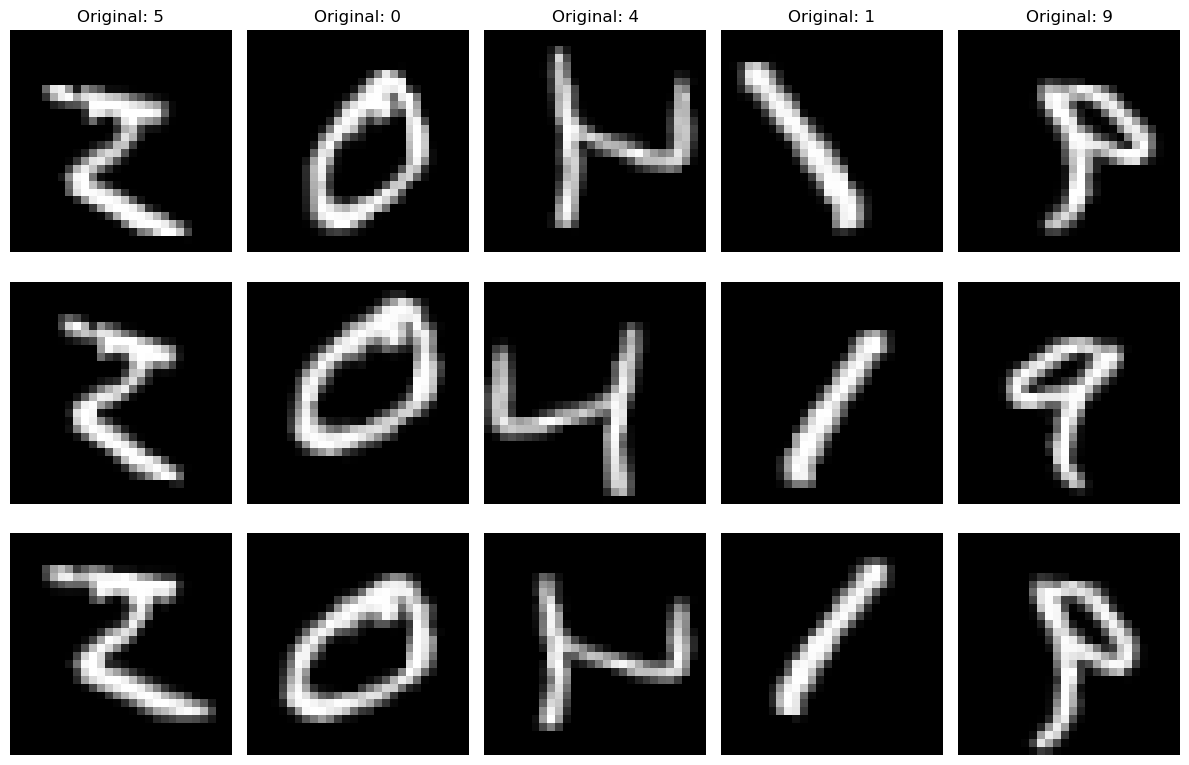

In [35]:
# Display augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i < 5:
        plt.title(f"Original: {y_train_img[i]}")
plt.tight_layout()
plt.show()

In [36]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [37]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

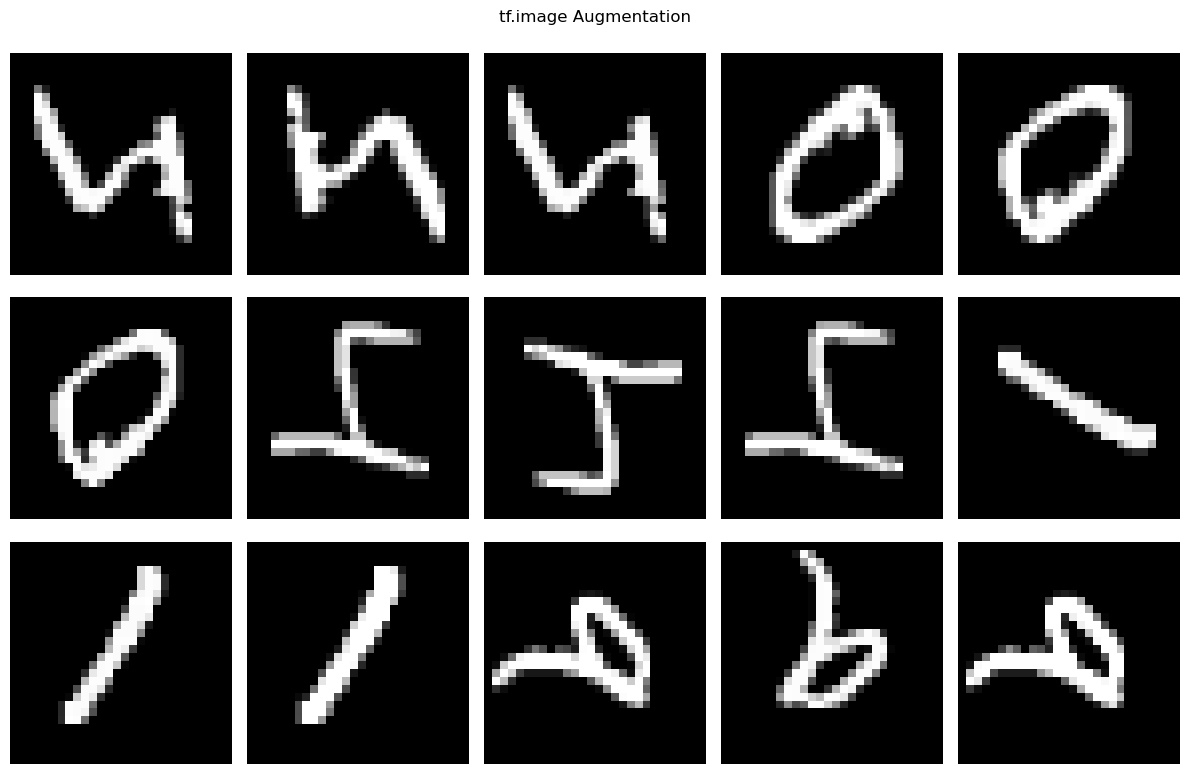

In [38]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [39]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

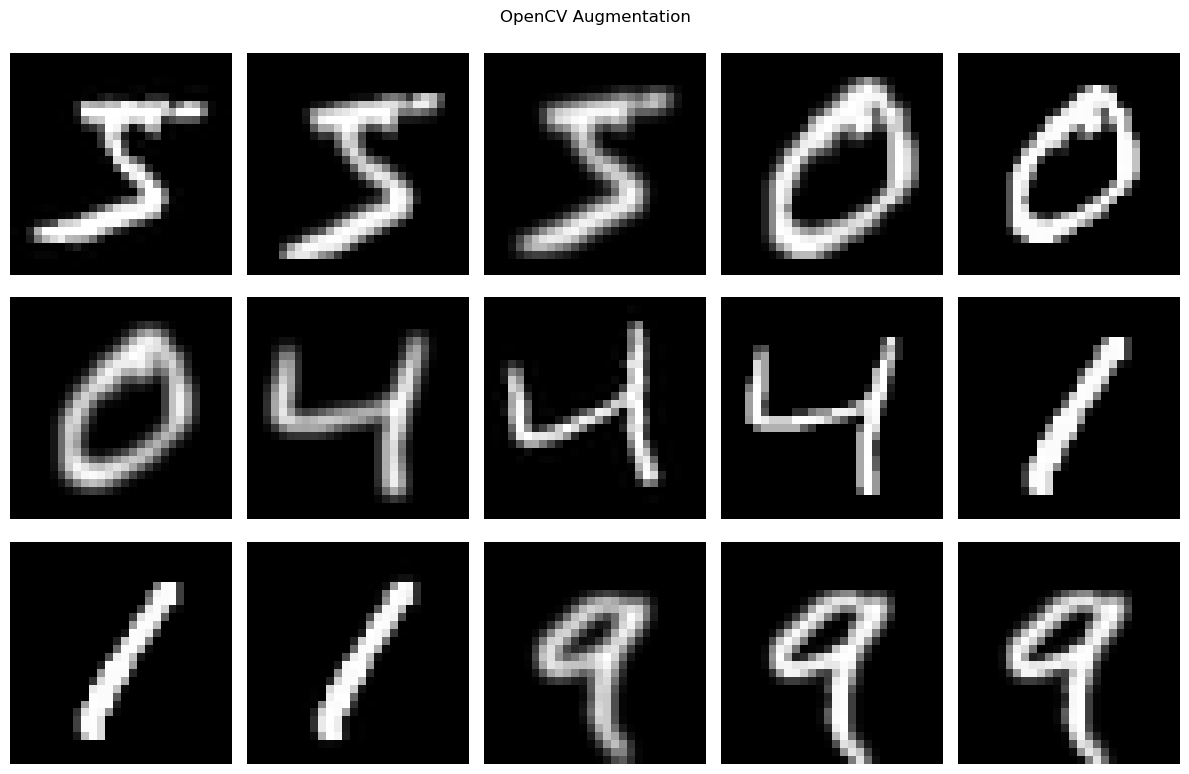

In [40]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

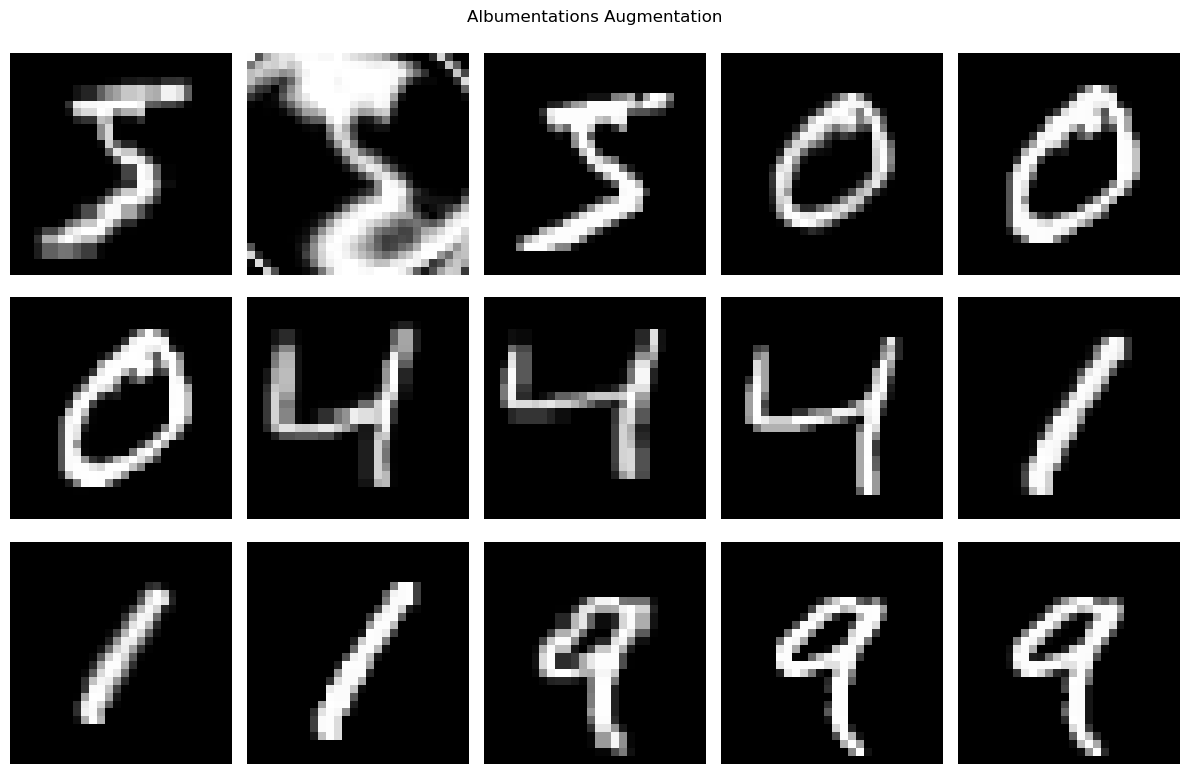

In [41]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [42]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [43]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [44]:
# Apply text augmentation
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [45]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: I is a great product, This love it!
Word Deletion: This is a great product, I love
Word Insertion: This is a great extremely product, I love it!
Original: The service was terrible and I'm disappointed.
Word Swap: I'm service was terrible and The disappointed.
Word Deletion: The was terrible and I'm disappointed.
Word Insertion: The service was terrible and somewhat I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: experience. not sure how I feel about this I'm
Word Deletion: I'm not sure how I feel about this
Word Insertion: I'm not sure how really I feel about this experience.
Original: The food was delicious and the staff was friendly.
Word Swap: and food was delicious The the staff was friendly.
Word Deletion: The food was and the staff was friendly.
Word Insertion: quite The food was delicious and the staff was friendly.
Original: This movie is boring and t

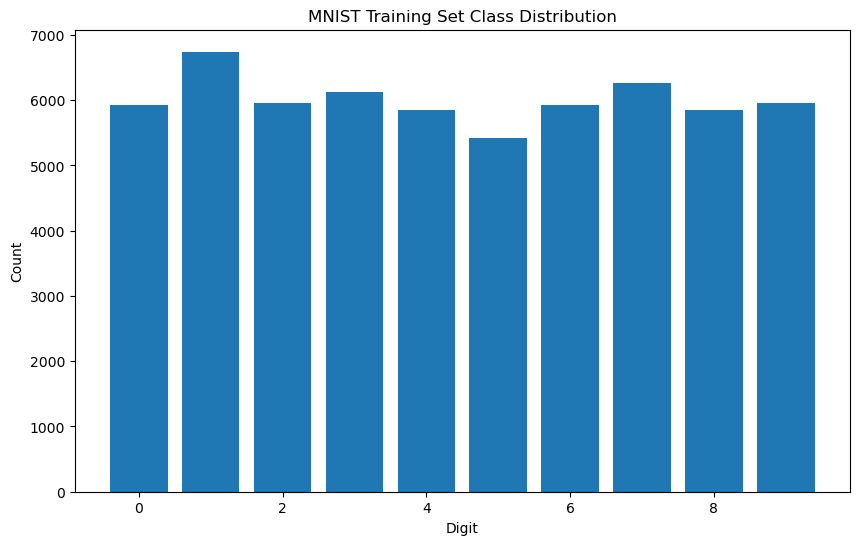

In [46]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

In [47]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [48]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially
X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train_img == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

In [49]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nInitial distribution:")
print(dict(zip(unique, counts)))


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [50]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [51]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [52]:
# Balance the dataset using augmentation
X_balanced, y_balanced = augment_minority_class(X_imbalanced, y_imbalanced, 8, 100)

# Print balanced distribution
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nBalanced distribution after augmentation:")
print(dict(zip(unique, counts)))


Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


In [53]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [54]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [55]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

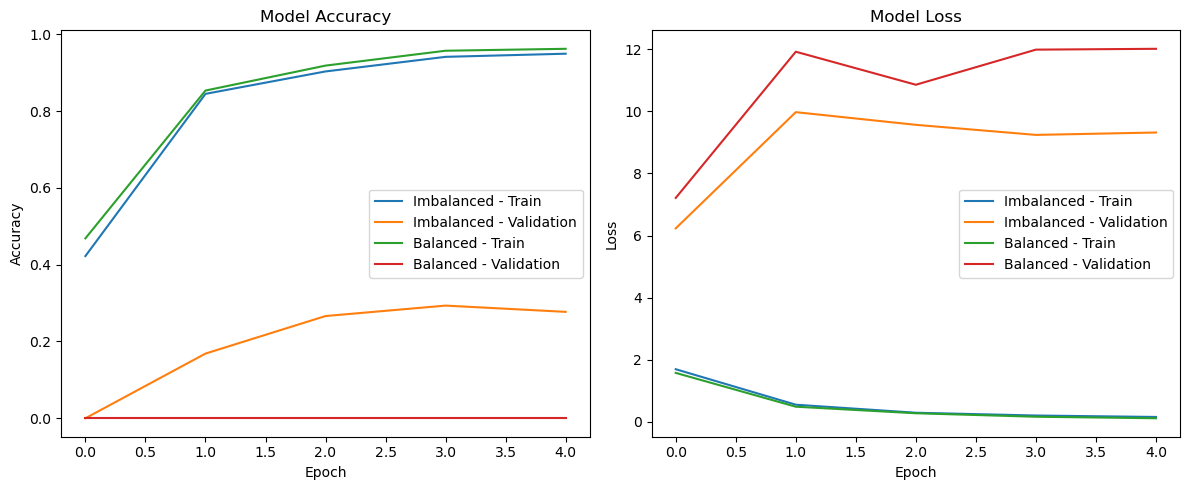

In [56]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
#Exercises!!!

In [58]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Display dataset shape
print(f"\nDataset Shape: {df.shape}")

# Print missing value counts per column
print("\nMissing Values per Column:")
print(df.isnull().sum())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Shape: (891, 12)

Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [59]:
# TODO: Fill missing 'Age' with its median
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print(f"Age median used: {age_median}")

# TODO: Fill missing 'Embarked' with its mode
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f"Embarked mode used: {embarked_mode}")

# TODO: Replace missing 'Cabin' entries with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Verify no missing values remain
print("\nMissing Values After Handling:")
print(df.isnull().sum())

Age median used: 28.0
Embarked mode used: S

Missing Values After Handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [60]:
# 3. Feature Engineering

# 3.1 Extract Title from Name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 3.2 Group rare titles and standardize
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Mlle', 'Mme', 'Ms']

title_mapping = {
    'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3,
    'Dr': 4, 'Rev': 4, 'Col': 4, 'Major': 4,
    'Mlle': 5, 'Mme': 5, 'Ms': 5, 'Lady': 5,
    'Sir': 5, 'Don': 5, 'Countess': 5, 'Dona': 5, 'Jonkheer': 5, 'Capt': 5
}
df['Title_Encoded'] = df['Title'].map(title_mapping).fillna(5).astype(int)

# 3.3 Family Size and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3.4 Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
bins_age = [0, 12, 18, 65, 100]
labels_age = ['Child', 'Teenager', 'Adult', 'Elderly']
df['AgeBin'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, right=False)

df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# 3.6 Deck from Cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'Unknown')
rare_decks = ['T', 'G', 'F']
df['Deck'] = df['Deck'].apply(lambda x: 'Other' if x in rare_decks else x)

print("✅ Feature Engineering Complete!")
print(f"\nNew Columns Added: {df.columns.tolist()}")

✅ Feature Engineering Complete!

New Columns Added: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Title_Encoded', 'FamilySize', 'IsAlone', 'FarePerPerson', 'AgeBin', 'FareBin', 'Deck']


In [61]:
# 4. Encoding and Scaling

# 4.1 One‑hot encode selected categorical columns
categorical = ['Pclass','Sex','Embarked','Title','AgeBin','FareBin','Deck']
df_encoded = pd.get_dummies(df[categorical], drop_first=True)
print(f"Encoded shape: {df_encoded.shape}")

# 4.2 Combine with numerical features
numerical = ['Age','SibSp','Parch','Fare','FamilySize','IsAlone','FarePerPerson']
X = pd.concat([df[numerical], df_encoded], axis=1)
y = df['Survived']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 4.3 Feature scaling: three different scalers
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rbv = RobustScaler()

X_std = scaler_std.fit_transform(X)
X_mm = scaler_mm.fit_transform(X)
X_rb = scaler_rbv.fit_transform(X)

print("\n✅ Encoding and Scaling Complete!")
print(f"Original X shape: {X.shape}")
print(f"Standardized shape: {X_std.shape}")
print(f"MinMax shape: {X_mm.shape}")
print(f"Robust shape: {X_rb.shape}")

Encoded shape: (891, 32)
X shape: (891, 39)
y shape: (891,)

✅ Encoding and Scaling Complete!
Original X shape: (891, 39)
Standardized shape: (891, 39)
MinMax shape: (891, 39)
Robust shape: (891, 39)


In [62]:
# 5. Feature Selection & Modeling

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# SelectKBest - Top 15 features
selector = SelectKBest(f_classif, k=15)
X_sel = selector.fit_transform(X_std, y)

top_feats = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).nlargest(15, 'Score')

print("=" * 50)
print("Top 15 Features by Score")
print("=" * 50)
print(top_feats)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.25, random_state=42
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# RandomForest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance (from RandomForest)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': top_feats['Feature'].values,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 50)
print("Feature Importances from RandomForest")
print("=" * 50)
print(feature_importance_df)

Top 15 Features by Score
              Feature       Score
22           Title_Mr  383.945495
8            Sex_male  372.405724
23          Title_Mrs  115.461086
7              Pclass  115.031272
19         Title_Miss  106.509051
38       Deck_Unknown   99.253142
3                Fare   63.030764
32  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
33             Deck_B   28.117228
35             Deck_D   20.663186
10         Embarked_S   20.374460
36             Deck_E   19.179221
34             Deck_C   11.841661

Training set: (668, 15)
Test set: (223, 15)

Accuracy: 0.8027

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       134
           1       0.73      0.80      0.76        89

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.80       223
weighted avg       0.81      0.80      0.80       223


Feature Importan

Polynomial Features (Degree=2)
Original shape: (891, 2)
Polynomial shape: (891, 5)
Feature names: ['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']

Original shape: (891, 39)
PCA shape: (891, 10)


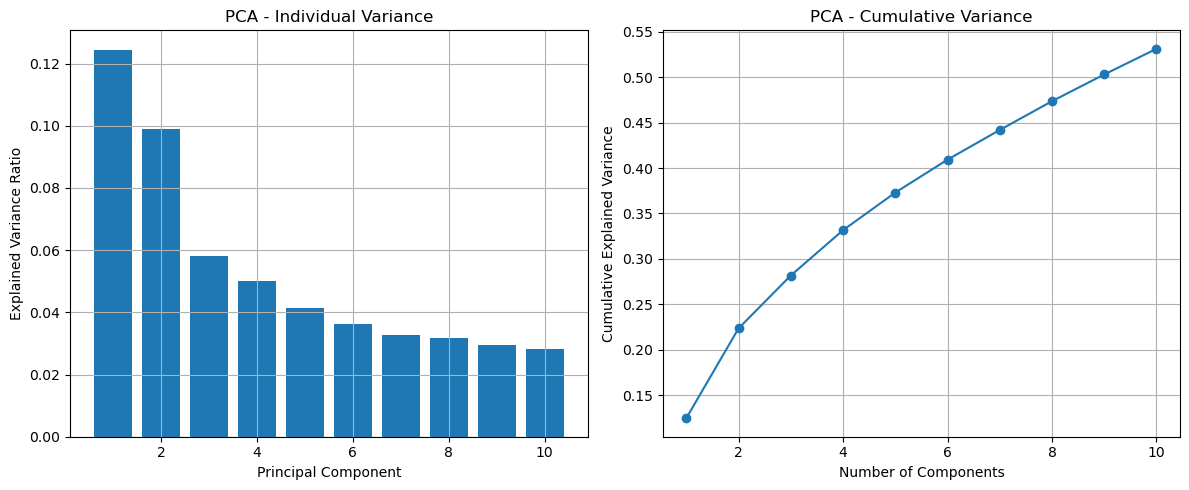


Cumulative Variance by Components
 1 components: 0.1244 (12.44%)
 2 components: 0.2234 (22.34%)
 3 components: 0.2817 (28.17%)
 4 components: 0.3316 (33.16%)
 5 components: 0.3730 (37.30%)
 6 components: 0.4093 (40.93%)
 7 components: 0.4420 (44.20%)
 8 components: 0.4737 (47.37%)
 9 components: 0.5032 (50.32%)
10 components: 0.5314 (53.14%)

✅ Advanced Feature Engineering Complete!


In [63]:
# 6. Advanced Feature Engineering

# 6.1 Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly.fit_transform(df[['Age','Fare']].fillna(0))

print("=" * 50)
print("Polynomial Features (Degree=2)")
print("=" * 50)
print(f"Original shape: (891, 2)")
print(f"Polynomial shape: {poly_data.shape}")
print(f"Feature names: {poly.get_feature_names_out(['Age','Fare'])}")

# 6.2 PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_std)

print(f"\nOriginal shape: {X_std.shape}")
print(f"PCA shape: {X_pca.shape}")

# 6.3 Explained variance plot
plt.figure(figsize=(12, 5))

# Individual variance
plt.subplot(1, 2, 1)
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Individual Variance')
plt.grid(True)

# Cumulative variance
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_[:10]), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Variance')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("Cumulative Variance by Components")
print("=" * 50)
for i, cum_var in enumerate(np.cumsum(pca.explained_variance_ratio_[:10]), 1):
    print(f"{i:2d} components: {cum_var:.4f} ({cum_var*100:.2f}%)")

print(f"\n✅ Advanced Feature Engineering Complete!")

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


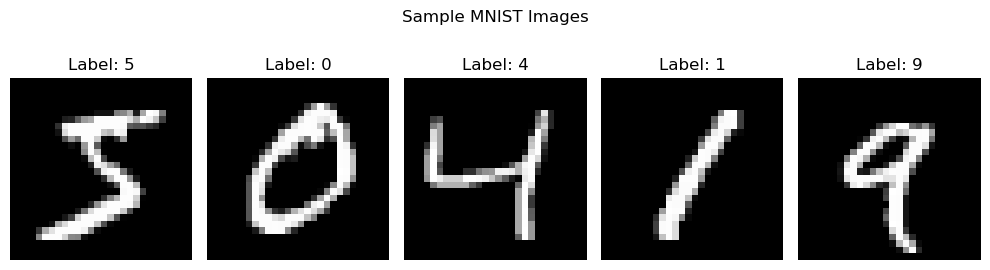

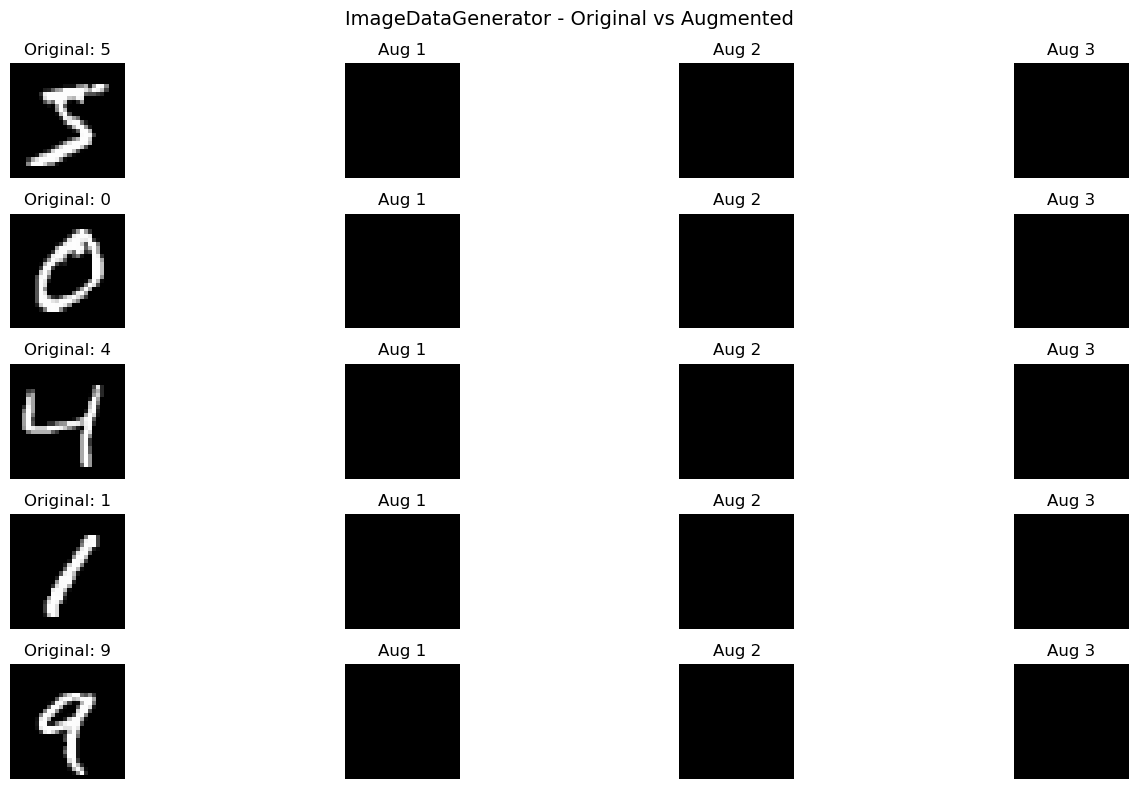

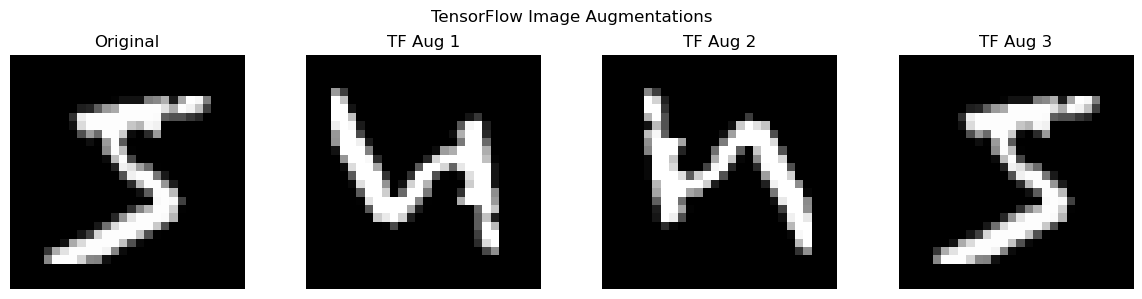

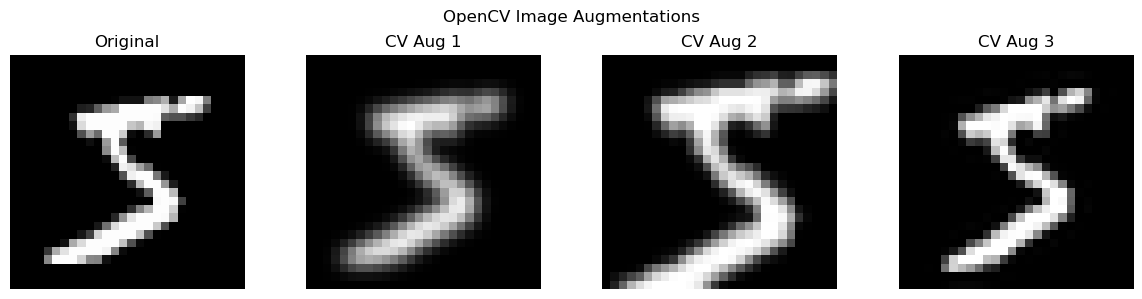

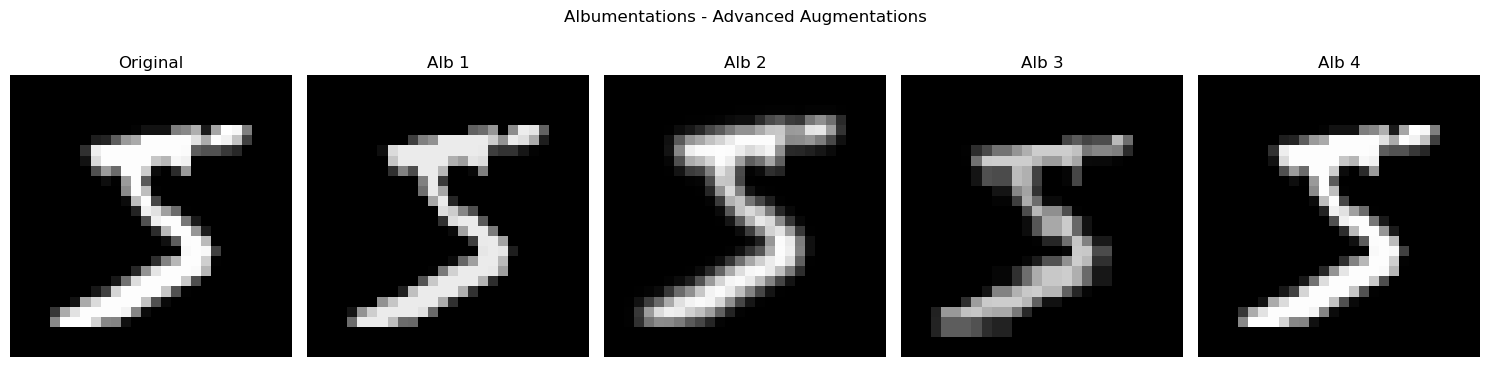


✅ All Image Augmentation Techniques Completed!


In [64]:
# 7. Image Data Augmentation

# 7.0 Load MNIST
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Training shape: {x_train.shape}")
print(f"Test shape: {x_test.shape}")

# 7.1 Display samples
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

# 7.2 ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, shear_range=0.1, brightness_range=[0.5, 1.5],
    horizontal_flip=True, fill_mode='nearest'
)
datagen.fit(x_train)

plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Original: {y_train[i]}')
    plt.axis('off')
    for j in range(3):
        aug_img = datagen.flow(x_train[i:i+1], batch_size=1)[0][0]
        plt.subplot(5, 4, i*4 + j + 2)
        plt.imshow(aug_img.reshape(28, 28), cmap='gray')
        plt.title(f'Aug {j+1}')
        plt.axis('off')
plt.suptitle('ImageDataGenerator - Original vs Augmented', fontsize=14)
plt.tight_layout()
plt.show()

# 7.3 tf.image augmentations
import tensorflow as tf

def tf_augment(image):
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return tf.clip_by_value(image, 0.0, 1.0)

sample = tf.convert_to_tensor(x_train[0], dtype=tf.float32)
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
plt.imshow(sample.numpy().reshape(28, 28), cmap='gray')
plt.title('Original')
plt.axis('off')
for i in range(3):
    plt.subplot(1, 4, i+2)
    aug_img = tf_augment(sample)
    plt.imshow(aug_img.numpy().reshape(28, 28), cmap='gray')
    plt.title(f'TF Aug {i+1}')
    plt.axis('off')
plt.suptitle('TensorFlow Image Augmentations')
plt.tight_layout()
plt.show()

# 7.4 OpenCV augmentations
import cv2
from scipy import ndimage

def opencv_augment(image):
    img_2d = (image.reshape(28, 28) * 255).astype(np.uint8)
    aug_type = np.random.choice(['rotate', 'blur', 'zoom'])
    
    if aug_type == 'rotate':
        rotated = ndimage.rotate(img_2d, np.random.uniform(-30, 30), reshape=False)
        return (rotated / 255.0).reshape(28, 28, 1)
    elif aug_type == 'blur':
        blurred = cv2.GaussianBlur(img_2d, (5, 5), 0)
        return (blurred / 255.0).reshape(28, 28, 1)
    elif aug_type == 'zoom':
        zoom_factor = np.random.uniform(0.7, 0.9)
        h, w = 28, 28
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
        start_h, start_w = (h - new_h) // 2, (w - new_w) // 2
        cropped = img_2d[start_h:start_h+new_h, start_w:start_w+new_w]
        zoomed = cv2.resize(cropped, (28, 28))
        return (zoomed / 255.0).reshape(28, 28, 1)

sample_img = x_train[0]
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title('Original')
plt.axis('off')
for i in range(3):
    aug_img = opencv_augment(sample_img)
    plt.subplot(1, 4, i+2)
    plt.imshow(aug_img.reshape(28, 28), cmap='gray')
    plt.title(f'CV Aug {i+1}')
    plt.axis('off')
plt.suptitle('OpenCV Image Augmentations')
plt.tight_layout()
plt.show()

# 7.5 Albumentations pipeline
import albumentations as A

albumentations_pipeline = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    A.OpticalDistortion(distort_limit=0.3, shift_limit=0.3, p=0.3)
])

sample_img = (x_train[0].reshape(28, 28) * 255).astype(np.uint8)
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_GRAY2RGB)

plt.figure(figsize=(15, 4))
plt.subplot(1, 5, 1)
plt.imshow(sample_img, cmap='gray')
plt.title('Original')
plt.axis('off')
for i in range(4):
    augmented = albumentations_pipeline(image=sample_rgb)['image']
    plt.subplot(1, 5, i+2)
    plt.imshow(augmented)
    plt.title(f'Alb {i+1}')
    plt.axis('off')
plt.suptitle('Albumentations - Advanced Augmentations')
plt.tight_layout()
plt.show()

print("\n✅ All Image Augmentation Techniques Completed!")

In [65]:
# 8. Text Data Augmentation

import random

# Sample sentences
texts = [
    "The Titanic sank on its maiden voyage.",
    "Machine learning models need lots of data.",
    "Data augmentation helps improve model performance."
]

# 8.1 Swap two random words
def swap_words(text):
    words = text.split()
    if len(words) < 2:
        return text
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return ' '.join(words)

# 8.2 Delete a random word
def delete_random_word(text):
    words = text.split()
    if len(words) < 2:
        return text
    idx = random.randint(0, len(words)-1)
    del words[idx]
    return ' '.join(words)

# 8.3 Insert a random word
def insert_random_word(text):
    words = text.split()
    if len(words) < 2:
        return text
    random_words = ['very', 'really', 'quite', 'extremely', 'absolutely', 'almost']
    idx = random.randint(0, len(words))
    new_word = random.choice(random_words)
    words.insert(idx, new_word)
    return ' '.join(words)

# 8.4 Apply augmentations
print("=" * 60)
print("TEXT DATA AUGMENTATION")
print("=" * 60)

for i, text in enumerate(texts):
    print(f"\n{'='*50}")
    print(f"📝 Original {i+1}: {text}")
    print(f"🔄 Swap words: {swap_words(text)}")
    print(f"🗑️ Delete word: {delete_random_word(text)}")
    print(f"➕ Insert word: {insert_random_word(text)}")

print("\n" + "=" * 60)
print("✅ Text Data Augmentation Complete!")
print("=" * 60)

TEXT DATA AUGMENTATION

📝 Original 1: The Titanic sank on its maiden voyage.
🔄 Swap words: The Titanic sank maiden its on voyage.
🗑️ Delete word: The sank on its maiden voyage.
➕ Insert word: The Titanic sank on its really maiden voyage.

📝 Original 2: Machine learning models need lots of data.
🔄 Swap words: Machine learning models of lots need data.
🗑️ Delete word: Machine learning models need of data.
➕ Insert word: Machine learning models need lots almost of data.

📝 Original 3: Data augmentation helps improve model performance.
🔄 Swap words: helps augmentation Data improve model performance.
🗑️ Delete word: Data augmentation helps improve performance.
➕ Insert word: Data almost augmentation helps improve model performance.

✅ Text Data Augmentation Complete!


Class Distribution Before Balancing
  Class 0:   5923 images
  Class 1:   6742 images
  Class 2:   5958 images
  Class 3:   6131 images
  Class 4:   5842 images
  Class 5:   5421 images
  Class 6:   5918 images
  Class 7:   6265 images
  Class 8:   5851 images
  Class 9:   5949 images

Minority Class: 5 (5421 images)
Target: 6742 images (matching majority)

✅ Class 5: 5421 → 6742 samples
   Generated 1321 new samples

Total dataset size: 61321 samples


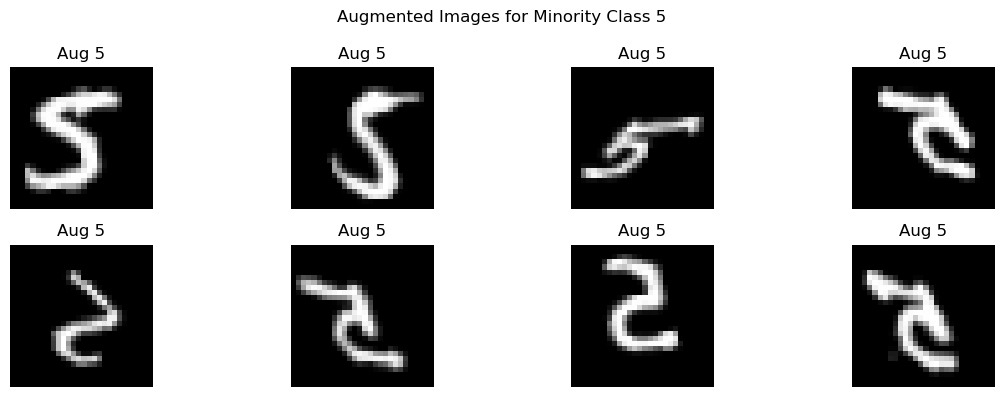


✅ Class Balancing Complete!


In [66]:
# 9. Class Balancing via Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# 9.1 Class distribution check
print("=" * 50)
print("Class Distribution Before Balancing")
print("=" * 50)
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count:6d} images")

# 9.2 Augment minority class
def augment_minority_class(X, y, target_class, num_samples):
    """
    Minority class ko augment karo
    """
    # Target class ke indices
    indices = np.where(y == target_class)[0]
    current_count = len(indices)
    samples_needed = num_samples - current_count
    
    if samples_needed <= 0:
        print(f"Class {target_class} already has {current_count} samples")
        return X, y
    
    X_target = X[indices]
    
    # ImageDataGenerator
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    augmented_images = []
    augmented_labels = []
    
    for img in X_target:
        img_reshaped = img.reshape(1, 28, 28, 1)
        gen = datagen.flow(img_reshaped, batch_size=1)
        
        for _ in range(int(np.ceil(samples_needed / current_count))):
            # ✅ FIX: gen.next() → next(gen)
            aug_img = next(gen)[0]
            augmented_images.append(aug_img)
            augmented_labels.append(target_class)
            
            if len(augmented_images) >= samples_needed:
                break
        
        if len(augmented_images) >= samples_needed:
            break
    
    augmented_images = np.array(augmented_images[:samples_needed])
    augmented_labels = np.array(augmented_labels[:samples_needed])
    
    X_balanced = np.concatenate([X, augmented_images], axis=0)
    y_balanced = np.concatenate([y, augmented_labels], axis=0)
    
    print(f"\n✅ Class {target_class}: {current_count} → {num_samples} samples")
    print(f"   Generated {len(augmented_images)} new samples")
    
    return X_balanced, y_balanced

# 9.3 Apply augmentation on minority class
min_class = unique[np.argmin(counts)]
max_count = max(counts)

print(f"\nMinority Class: {min_class} ({min(counts)} images)")
print(f"Target: {max_count} images (matching majority)")

X_balanced, y_balanced = augment_minority_class(
    x_train, y_train, 
    target_class=min_class, 
    num_samples=max_count
)

print(f"\nTotal dataset size: {len(X_balanced)} samples")

# 9.4 Show some augmented images
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    # Display augmented images of minority class
    idx = np.where(y_balanced == min_class)[0][i + counts[0]]
    plt.imshow(X_balanced[idx].reshape(28, 28), cmap='gray')
    plt.title(f'Aug {min_class}')
    plt.axis('off')
plt.suptitle(f'Augmented Images for Minority Class {min_class}')
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("✅ Class Balancing Complete!")
print("=" * 50)

EFFECT OF AUGMENTATION ON MODEL PERFORMANCE
Imbalanced dataset shape: (920, 28, 28, 1)
Class Distribution:
  Class 0: 100 samples
  Class 1: 100 samples
  Class 2: 100 samples
  Class 3: 100 samples
  Class 4: 100 samples
  Class 5: 100 samples
  Class 6: 100 samples
  Class 7: 100 samples
  Class 8: 20 samples
  Class 9: 100 samples
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5245 - loss: 1.7604 - val_accuracy: 0.6793 - val_loss: 1.0447
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8179 - loss: 0.6293 - val_accuracy: 0.8587 - val_loss: 0.5130
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8804 - loss: 0.3849 - val_accuracy: 0.8587 - val_loss: 0.4115
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9266 - loss: 0.2440 - val_accuracy: 0.9022 - val_loss: 0.3294
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9280 - loss: 0.2081 - val_accuracy: 0.9293 - val_loss: 0.2756
Epoch 6/10
23/23 ━━━━━━━━━━━━

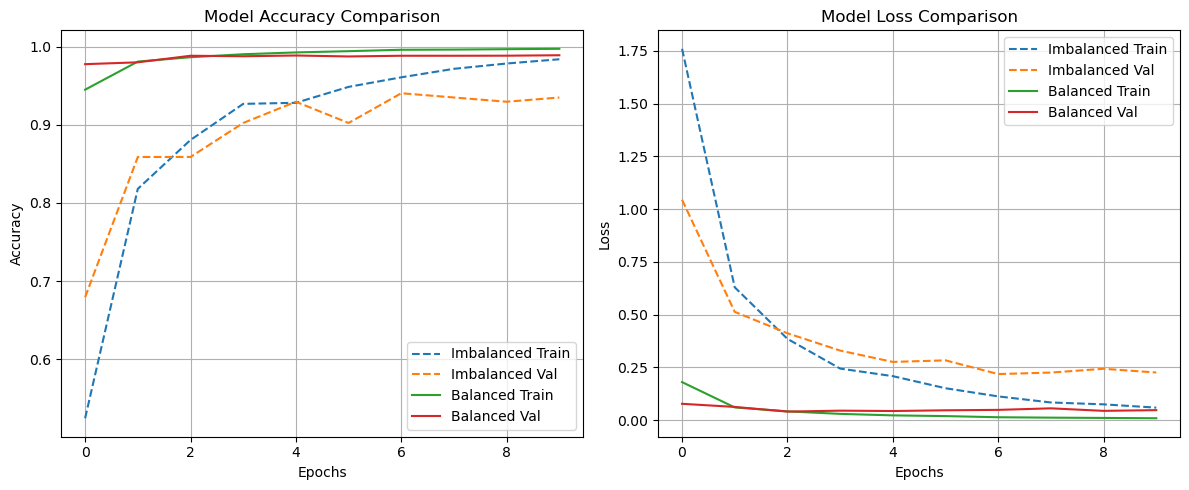


✅ Effect of Augmentation Analysis Complete!


In [67]:
# 10. Effect of Augmentation on Model Performance

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 10.1 Create CNN model
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 10.2 Create imbalanced subset
def create_imbalanced_subset(X, y, samples_per_class=100, minority_class=8, minority_samples=20):
    X_subset, y_subset = [], []
    for cls in range(10):
        idx = np.where(y == cls)[0]
        if cls == minority_class:
            selected = np.random.choice(idx, min(minority_samples, len(idx)), replace=False)
        else:
            selected = np.random.choice(idx, min(samples_per_class, len(idx)), replace=False)
        X_subset.append(X[selected])
        y_subset.append(y[selected])
    X_subset = np.concatenate(X_subset, axis=0)
    y_subset = np.concatenate(y_subset, axis=0)
    
    print(f"Imbalanced dataset shape: {X_subset.shape}")
    unique, counts = np.unique(y_subset, return_counts=True)
    print("Class Distribution:")
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples")
    return X_subset, y_subset

print("=" * 50)
print("EFFECT OF AUGMENTATION ON MODEL PERFORMANCE")
print("=" * 50)

# 10.3 Train on imbalanced data
X_imb, y_imb = create_imbalanced_subset(x_train, y_train, samples_per_class=100, minority_class=8, minority_samples=20)
shuffle_idx = np.random.permutation(len(X_imb))
X_imb, y_imb = X_imb[shuffle_idx], y_imb[shuffle_idx]
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)

model_imb = create_model()
history_imb = model_imb.fit(X_imb_train, y_imb_train, epochs=10, batch_size=32, validation_data=(X_imb_test, y_imb_test), verbose=1)
test_loss_imb, test_acc_imb = model_imb.evaluate(X_imb_test, y_imb_test, verbose=0)
print(f"\nImbalanced Model - Test Accuracy: {test_acc_imb:.4f}")

# 10.4 Train on balanced data
shuffle_idx_bal = np.random.permutation(len(X_balanced))
X_bal, y_bal = X_balanced[shuffle_idx_bal], y_balanced[shuffle_idx_bal]
X_bal_train, X_bal_test, y_bal_train, y_bal_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

model_bal = create_model()
history_bal = model_bal.fit(X_bal_train, y_bal_train, epochs=10, batch_size=32, validation_data=(X_bal_test, y_bal_test), verbose=1)
test_loss_bal, test_acc_bal = model_bal.evaluate(X_bal_test, y_bal_test, verbose=0)
print(f"\nBalanced Model - Test Accuracy: {test_acc_bal:.4f}")

# 10.5 Compare and plot
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Imbalanced Model - Test Accuracy: {test_acc_imb:.4f}")
print(f"Balanced Model - Test Accuracy: {test_acc_bal:.4f}")
print(f"Improvement: {(test_acc_bal - test_acc_imb) * 100:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imb.history['accuracy'], label='Imbalanced Train', linestyle='--')
plt.plot(history_imb.history['val_accuracy'], label='Imbalanced Val', linestyle='--')
plt.plot(history_bal.history['accuracy'], label='Balanced Train')
plt.plot(history_bal.history['val_accuracy'], label='Balanced Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_imb.history['loss'], label='Imbalanced Train', linestyle='--')
plt.plot(history_imb.history['val_loss'], label='Imbalanced Val', linestyle='--')
plt.plot(history_bal.history['loss'], label='Balanced Train')
plt.plot(history_bal.history['val_loss'], label='Balanced Val')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("✅ Effect of Augmentation Analysis Complete!")
print("=" * 50)